# Assignment 3 — Phase 1: Data Preparation
## VizWiz Image Captioning

This notebook covers all shared data preparation steps:
1. Dataset loading and inspection
2. Caption cleaning and tokenisation
3. Vocabulary construction
4. Train / validation / test splitting
5. Dataset and DataLoader classes

**Important note on the dataset:** VizWiz is a blind-photography dataset. Many images are
blurry, poorly framed, or dark. Some captions explicitly flag quality issues (e.g. 'quality
issues prevent a complete answer'). We handle these deliberately rather than silently.

## 0. Imports and Configuration

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scipy scikit-learn torch torchvision torchsummary tqdm


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import os
import re
import json
import random
import string
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

PROCESSED_DATA_DIR = DATA_DIR / "processed"
IMAGE_DIR = RAW_DATA_DIR / "val"
ANNOTATIONS_PATH = RAW_DATA_DIR / "annotations" / "val.json"

print("Project root:", PROJECT_ROOT)
print("Image directory:", IMAGE_DIR)
print("Annotations path:", ANNOTATIONS_PATH)

assert IMAGE_DIR.exists(), f"Image directory not found: {IMAGE_DIR}"
assert ANNOTATIONS_PATH.exists(), f"Annotations file not found: {ANNOTATIONS_PATH}"

print("Data paths verified.")
print("="*50)

# ── Vocabulary / sequence settings ────────────────────────────────────────────
MIN_WORD_FREQ = 5      # words appearing fewer times are mapped to <UNK>
MAX_CAPTION_LEN = 50   # captions longer than this are truncated

# ── Split ratios image-level ──────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# TEST_RATIO = 0.15 implicit: whatever remains

# ── DataLoader settings ───────────────────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 0        # safer for Mac/Jupyter

# ── Device setup for Mac Apple Silicon GPU ────────────────────────────────────
print("Torch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Device:", DEVICE)

Project root: /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3
Image directory: /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/data/raw/val
Annotations path: /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/data/raw/annotations/val.json
Data paths verified.
Torch version: 2.12.0
MPS available: True
Device: mps


## 1. Loading the Dataset

VizWiz annotations follow the COCO JSON format:
```
{
  "images":      [{"id": int, "file_name": str, ...}, ...],
  "annotations": [{"image_id": int, "caption": str, ...}, ...]
}
```
Each image has exactly **5** annotations.

In [3]:
with open(ANNOTATIONS_PATH, "r") as f:
    raw = json.load(f)

print(f"Top-level keys : {list(raw.keys())}")
print(f"Number of images      : {len(raw['images'])}")
print(f"Number of annotations : {len(raw['annotations'])}")
print(f"Captions per image    : {len(raw['annotations']) / len(raw['images']):.1f}")

Top-level keys : ['info', 'images', 'annotations']
Number of images      : 7750
Number of annotations : 38750
Captions per image    : 5.0


In [4]:
# Build a lookup: image_id → file_name
id_to_filename: Dict[int, str] = {
    img["id"]: img["file_name"] for img in raw["images"]
}

# Group all 5 captions under their image_id
id_to_captions: Dict[int, List[str]] = {}
for ann in raw["annotations"]:
    iid = ann["image_id"]
    id_to_captions.setdefault(iid, []).append(ann["caption"])

# Sanity-check: confirm every image has exactly 5 captions
caption_counts = Counter(len(v) for v in id_to_captions.values())
print("Caption count distribution:", dict(caption_counts))

Caption count distribution: {5: 7750}


In [5]:
# Flatten into a DataFrame for easy inspection
records = []
for iid, captions in id_to_captions.items():
    for cap in captions:
        records.append({"image_id": iid,
                        "file_name": id_to_filename[iid],
                        "caption": cap})

df = pd.DataFrame(records)
print(df.shape)
df.head(10)

(38750, 3)


,image_id,file_name,caption
0,23431,VizWiz_val_00000000.jpg,A computer screen shows a repair prompt on the...
1,23431,VizWiz_val_00000000.jpg,a computer screen with a repair automatically ...
2,23431,VizWiz_val_00000000.jpg,partial computer screen showing the need of re...
3,23431,VizWiz_val_00000000.jpg,Part of a computer monitor showing a computer ...
4,23431,VizWiz_val_00000000.jpg,The top of a laptop with a blue background and...
5,23432,VizWiz_val_00000001.jpg,A person is holding a bottle that has medicine...
6,23432,VizWiz_val_00000001.jpg,A bottle of medication has a white twist top.
7,23432,VizWiz_val_00000001.jpg,night time medication bottle being held by som...
8,23432,VizWiz_val_00000001.jpg,a person holding a small black bottle of NIGHT...
9,23432,VizWiz_val_00000001.jpg,A bottle of what appears to be cough syrup hel...


### 1.1 Quick Visual Inspection
Let's look at a handful of images alongside their captions to get a feel for the dataset.

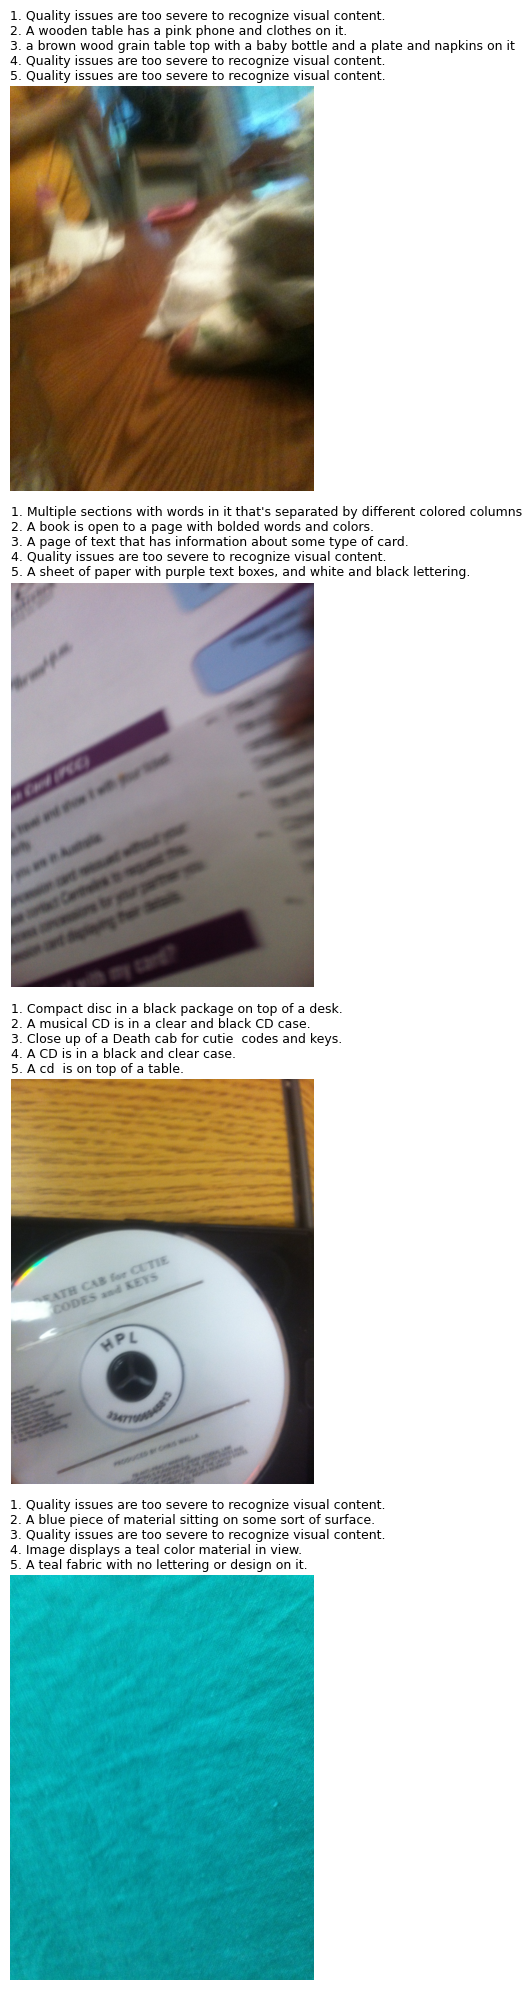

Displayed 4 images with their captions.


In [6]:
def show_sample(image_ids: List[int], n_cols: int = 3) -> None:
    """Display images with all five reference captions."""
    n_rows = len(image_ids)
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 5 * n_rows))
    if n_rows == 1:
        axes = [axes]
    for ax, iid in zip(axes, image_ids):
        path = IMAGE_DIR / id_to_filename[iid]
        img  = mpimg.imread(path)
        ax.imshow(img)
        ax.axis("off")
        caps = "\n".join(f"{i+1}. {c}" for i, c in enumerate(id_to_captions[iid]))
        ax.set_title(caps, fontsize=9, loc="left", wrap=True)
    plt.tight_layout()
    plt.show()
    print(f"Displayed {len(image_ids)} images with their captions.")

sample_ids = random.sample(list(id_to_captions.keys()), 4)
show_sample(sample_ids)

## 2. Caption Cleaning and Tokenisation

### Design decisions:
- **Lowercase** everything — reduces vocabulary size without meaningful loss.
- **Remove punctuation** except apostrophes in contractions (don't → dont is fine; we keep it simple and strip all punctuation uniformly).
- **Strip quality-issue captions**: VizWiz captions sometimes contain the marker phrase
  `"quality issues"`. We flag but do **not** automatically remove them — they may still
  contain partial signal, and removing them would introduce a selection bias into our splits.
- **Truncate** captions longer than `MAX_CAPTION_LEN` tokens to prevent runaway sequences.
- We do **not** perform stemming or lemmatisation — that would hurt BLEU scores since
  BLEU compares n-gram surface forms.

In [7]:
# Compile once for efficiency
_PUNCT_RE = re.compile(r"[^\w\s]")
_SPACE_RE = re.compile(r"\s+")

def clean_caption(text: str) -> str:
    """
    Normalise a raw caption string.

    Steps:
      1. Lowercase
      2. Strip punctuation (non-word, non-space chars)
      3. Collapse multiple whitespace to a single space
      4. Strip leading/trailing whitespace
    """
    text = text.lower()
    text = _PUNCT_RE.sub(" ", text)
    text = _SPACE_RE.sub(" ", text)
    return text.strip()


def tokenise(text: str) -> List[str]:
    """Split a cleaned caption into a list of word tokens."""
    return text.split()


# ── Demonstration ──────────────────────────────────────────────────────────────
examples = [
    "A blurry photo of a white dog.",
    "Quality issues prevent a complete answer.",
    "  The   label reads: 'Best before Jan 2024'.  ",
]
for e in examples:
    cleaned = clean_caption(e)
    print(f"  Raw    : {e!r}")
    print(f"  Cleaned: {cleaned!r}")
    print(f"  Tokens : {tokenise(cleaned)}")
    print()

  Raw    : 'A blurry photo of a white dog.'
  Cleaned: 'a blurry photo of a white dog'
  Tokens : ['a', 'blurry', 'photo', 'of', 'a', 'white', 'dog']

  Raw    : 'Quality issues prevent a complete answer.'
  Cleaned: 'quality issues prevent a complete answer'
  Tokens : ['quality', 'issues', 'prevent', 'a', 'complete', 'answer']

  Raw    : "  The   label reads: 'Best before Jan 2024'.  "
  Cleaned: 'the label reads best before jan 2024'
  Tokens : ['the', 'label', 'reads', 'best', 'before', 'jan', '2024']



In [8]:
# Apply cleaning to the full dataframe
df["caption_clean"]  = df["caption"].apply(clean_caption)
df["tokens"]         = df["caption_clean"].apply(tokenise)
df["token_length"]   = df["tokens"].apply(len)

# Flag potential quality-issue captions
df["quality_issue"]  = df["caption_clean"].str.contains("quality issues", na=False)

print(f"Captions flagged as quality issues : {df['quality_issue'].sum()} "
      f"({df['quality_issue'].mean()*100:.1f}%)")
print()
print("Caption length statistics (tokens):")
print(df["token_length"].describe().to_string())

Captions flagged as quality issues : 5204 (13.4%)

Caption length statistics (tokens):
count    38750.000000
mean        11.723923
std          4.218449
min          6.000000
25%          9.000000
50%         10.000000
75%         13.000000
max        156.000000


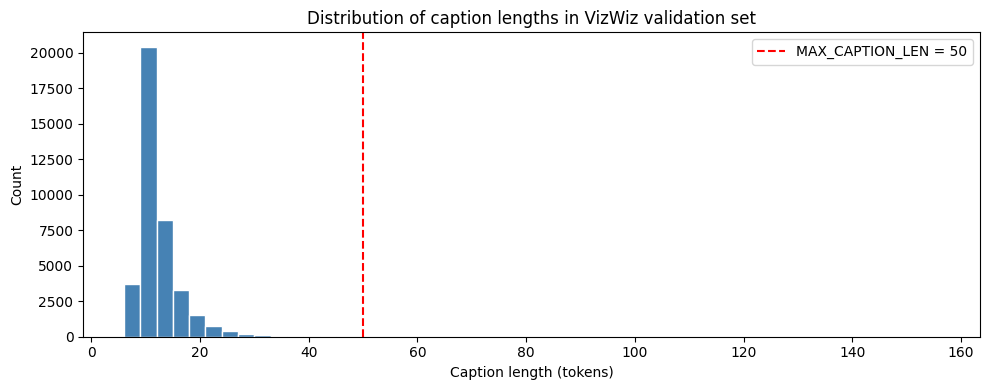

Captions that exceed MAX_CAPTION_LEN=50: 17 (0.04%)


In [9]:
# Visualise caption length distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["token_length"], bins=50, color="steelblue", edgecolor="white")
ax.axvline(MAX_CAPTION_LEN, color="red", linestyle="--",
           label=f"MAX_CAPTION_LEN = {MAX_CAPTION_LEN}")
ax.set_xlabel("Caption length (tokens)")
ax.set_ylabel("Count")
ax.set_title("Distribution of caption lengths in VizWiz validation set")
ax.legend()
plt.tight_layout()
plt.show()

truncated = (df["token_length"] > MAX_CAPTION_LEN).sum()
print(f"Captions that exceed MAX_CAPTION_LEN={MAX_CAPTION_LEN}: "
      f"{truncated} ({truncated/len(df)*100:.2f}%)")

In [10]:
# Truncate tokens that exceed the max length
df["tokens"] = df["tokens"].apply(lambda t: t[:MAX_CAPTION_LEN])
df["token_length"] = df["tokens"].apply(len)

## 3. Vocabulary Construction

### Design decisions:
- **Special tokens** — four reserved tokens with fixed indices:
  - `<PAD>` (index 0): padding to align sequences in a batch
  - `<START>` (index 1): prepended to every target sequence during training
  - `<END>` (index 2): appended to every target sequence; the decoder should learn to stop here
  - `<UNK>` (index 3): any word below the frequency threshold
- **MIN_WORD_FREQ = 5**: words appearing fewer than 5 times contribute little signal and inflate the softmax head unnecessarily.

In [11]:
class Vocabulary:
    """
    Bidirectional word ↔ index mapping.

    Special token layout (fixed):
        0 : <PAD>
        1 : <START>
        2 : <END>
        3 : <UNK>
    """

    PAD_TOKEN   = "<PAD>"
    START_TOKEN = "<START>"
    END_TOKEN   = "<END>"
    UNK_TOKEN   = "<UNK>"

    PAD_IDX   = 0
    START_IDX = 1
    END_IDX   = 2
    UNK_IDX   = 3

    def __init__(self, min_freq: int = 5) -> None:
        self.min_freq = min_freq
        self.word2idx: Dict[str, int] = {}
        self.idx2word: Dict[int, str] = {}
        self._init_special_tokens()

    def _init_special_tokens(self) -> None:
        specials = [self.PAD_TOKEN, self.START_TOKEN,
                    self.END_TOKEN, self.UNK_TOKEN]
        for idx, tok in enumerate(specials):
            self.word2idx[tok] = idx
            self.idx2word[idx] = tok

    def build(self, token_lists: List[List[str]]) -> None:
        """
        Build vocabulary from a list of token sequences.
        Only tokens appearing >= min_freq times are added.
        """
        counter = Counter(tok for tokens in token_lists for tok in tokens)
        # Sort alphabetically for determinism
        for word in sorted(counter):
            if counter[word] >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        print(f"Vocabulary built: {len(self)} tokens "
              f"(min_freq={self.min_freq}, "
              f"discarded {len(counter) - (len(self) - 4)} rare tokens)")

    def encode(self, tokens: List[str]) -> List[int]:
        """Convert token list → index list, wrapping with <START>/<END>."""
        return (
            [self.START_IDX]
            + [self.word2idx.get(t, self.UNK_IDX) for t in tokens]
            + [self.END_IDX]
        )

    def decode(self, indices: List[int], skip_special: bool = True) -> str:
        """Convert index list → sentence string."""
        special = {self.PAD_IDX, self.START_IDX, self.END_IDX}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                continue
            if idx == self.END_IDX:
                break
            words.append(self.idx2word.get(idx, self.UNK_TOKEN))
        return " ".join(words)

    def __len__(self) -> int:
        return len(self.word2idx)

    def __contains__(self, word: str) -> bool:
        return word in self.word2idx

## 4. Train / Validation / Test Splitting

### Critical design decision — split at the **image level**

We must split by `image_id`, not by row. If we split by row, the same image's captions
could appear in both train and test, creating a data leakage problem where the model
has effectively seen the image during training.

Split ratios: **70% train / 15% val / 15% test** (applied to 7,750 unique images).

In [12]:
all_image_ids = list(id_to_captions.keys())
random.shuffle(all_image_ids)   # seeded above for reproducibility

n_total = len(all_image_ids)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
# n_test picks up the remainder to avoid rounding loss

train_ids = set(all_image_ids[:n_train])
val_ids   = set(all_image_ids[n_train : n_train + n_val])
test_ids  = set(all_image_ids[n_train + n_val:])

print(f"Total images : {n_total}")
print(f"  Train      : {len(train_ids)}  ({len(train_ids)/n_total*100:.1f}%)")
print(f"  Validation : {len(val_ids)}   ({len(val_ids)/n_total*100:.1f}%)")
print(f"  Test       : {len(test_ids)}   ({len(test_ids)/n_total*100:.1f}%)")

# Verify no overlap
assert train_ids.isdisjoint(val_ids),  "Leakage: train ∩ val is non-empty!"
assert train_ids.isdisjoint(test_ids), "Leakage: train ∩ test is non-empty!"
assert val_ids.isdisjoint(test_ids),   "Leakage: val ∩ test is non-empty!"
print("✓ No overlap between splits.")

Total images : 7750
  Train      : 5425  (70.0%)
  Validation : 1162   (15.0%)
  Test       : 1163   (15.0%)
✓ No overlap between splits.


In [13]:
# Annotate the dataframe with split labels
def assign_split(iid: int) -> str:
    if iid in train_ids: return "train"
    if iid in val_ids:   return "val"
    return "test"

df["split"] = df["image_id"].apply(assign_split)

print(df.groupby("split").size().rename("caption_rows").to_string())

split
test      5815
train    27125
val       5810


In [14]:
# Now build vocabulary — ONLY from training tokens to prevent leakage
train_tokens = df.loc[df["split"] == "train", "tokens"].tolist()

vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build(train_tokens)

print(f"\nExample encode → decode round-trip:")
sample_tokens = df.loc[df["split"] == "train", "tokens"].iloc[0]
encoded = vocab.encode(sample_tokens)
decoded = vocab.decode(encoded)
print(f"  Tokens  : {sample_tokens}")
print(f"  Encoded : {encoded}")
print(f"  Decoded : {decoded}")

Vocabulary built: 3274 tokens (min_freq=5, discarded 5983 rare tokens)

Example encode → decode round-trip:
  Tokens  : ['a', 'computer', 'screen', 'shows', 'a', 'repair', 'prompt', 'on', 'the', 'screen']
  Encoded : [1, 55, 659, 2482, 2572, 55, 2362, 2269, 1957, 2917, 2482, 2]
  Decoded : a computer screen shows a repair prompt on the screen


In [15]:
# Measure OOV (out-of-vocabulary) rate on val and test sets
for split_name in ["val", "test"]:
    split_tokens = df.loc[df["split"] == split_name, "tokens"]
    total, oov = 0, 0
    for toks in split_tokens:
        for t in toks:
            total += 1
            if t not in vocab:
                oov += 1
    print(f"{split_name} OOV rate: {oov/total*100:.2f}%  ({oov}/{total} tokens)")

val OOV rate: 4.42%  (3003/67925 tokens)
test OOV rate: 4.64%  (3146/67779 tokens)


## 5. Image Transforms

### Design decisions:
- **Resize to 224×224**: standard input size for ImageNet pretrained CNNs (ResNet, EfficientNet, etc.).
- **ImageNet normalisation**: mean and std derived from the ImageNet training set. Since
  we will freeze or fine-tune a pretrained encoder, the input distribution should match
  what the encoder was trained on.
- **Training augmentation**: random horizontal flip only. We avoid aggressive augmentation
  (colour jitter, random crop) because the VizWiz images are already diverse and low-quality;
  strong augmentation could destroy what little signal exists.
- Val/test transforms are deterministic (no augmentation).

In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined.")

Transforms defined.


## 6. Dataset Class

### Design decisions:
- **Training**: returns one randomly sampled caption per image per iteration.
  Training on all 5 captions simultaneously would require special loss handling;
  random sampling is simpler and still exposes the model to caption diversity over epochs.
- **Val / Test**: returns **all 5 reference captions** so we can compute corpus-level
  BLEU against multiple references, which is the correct evaluation protocol.
- Images that cannot be loaded (corrupt file) are skipped at build time with a warning.

In [17]:
class VizWizDataset(Dataset):
    """
    PyTorch Dataset for the VizWiz image captioning task.

    Training mode
    -------------
    Returns: (image_tensor, caption_tensor, caption_length)
    One randomly sampled caption per image. Caption is encoded as a
    1-D LongTensor with <START> and <END> tokens included.

    Eval mode (val / test)
    ----------------------
    Returns: (image_tensor, all_captions_encoded, all_caption_lengths)
    all_captions_encoded is a list of 5 LongTensors (unpadded).
    """

    def __init__(
        self,
        image_ids: List[int],
        id_to_filename: Dict[int, str],
        id_to_captions_clean: Dict[int, List[List[str]]],  # tokenised, cleaned
        vocab: Vocabulary,
        image_dir: Path,
        transform: transforms.Compose,
        training: bool = True,
    ) -> None:
        self.vocab     = vocab
        self.image_dir = image_dir
        self.transform = transform
        self.training  = training

        # Filter to images that actually exist on disk
        self.samples: List[Tuple[int, str, List[List[str]]]] = []
        missing = 0
        for iid in image_ids:
            fname = id_to_filename[iid]
            path  = image_dir / fname
            if not path.exists():
                missing += 1
                continue
            self.samples.append((iid, fname, id_to_captions_clean[iid]))

        if missing:
            print(f"[Warning] {missing} images not found on disk and were skipped.")
        print(f"Dataset ({'train' if training else 'eval'}): "
              f"{len(self.samples)} images loaded.")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        iid, fname, token_lists = self.samples[idx]

        # ── Load and transform image ───────────────────────────────────────────
        image = Image.open(self.image_dir / fname).convert("RGB")
        image = self.transform(image)

        # ── Encode captions ───────────────────────────────────────────────────
        if self.training:
            # Sample one caption randomly
            tokens  = random.choice(token_lists)
            encoded = self.vocab.encode(tokens)
            caption = torch.tensor(encoded, dtype=torch.long)
            return image, caption, torch.tensor(len(encoded), dtype=torch.long)
        else:
            # Return all 5 captions for multi-reference BLEU evaluation
            all_encoded = [
                torch.tensor(self.vocab.encode(toks), dtype=torch.long)
                for toks in token_lists
            ]
            lengths = torch.tensor([len(e) for e in all_encoded], dtype=torch.long)
            return image, all_encoded, lengths

print("VizWizDataset class defined.")

VizWizDataset class defined.


## 7. Collate Functions

PyTorch's default collate cannot handle variable-length sequences. We write custom
collate functions for both training and evaluation modes.

In [18]:
def collate_train(batch):
    """
    Collate for training batches.

    Returns
    -------
    images   : FloatTensor  (B, 3, 224, 224)
    captions : LongTensor   (B, T_max)  — padded with PAD_IDX=0
    lengths  : LongTensor   (B,)        — actual length of each sequence
    """
    images, captions, lengths = zip(*batch)
    images   = torch.stack(images, dim=0)
    # pad_sequence expects (T, B); we transpose back to (B, T)
    captions = pad_sequence(captions,
                            batch_first=True,
                            padding_value=Vocabulary.PAD_IDX)
    lengths  = torch.stack(lengths, dim=0)
    return images, captions, lengths


def collate_eval(batch):
    """
    Collate for evaluation batches.

    Returns
    -------
    images       : FloatTensor  (B, 3, 224, 224)
    all_captions : List[List[LongTensor]]  — outer=batch, inner=5 refs each
    all_lengths  : LongTensor   (B, 5)
    """
    images, all_captions, all_lengths = zip(*batch)
    images      = torch.stack(images, dim=0)
    all_lengths = torch.stack(all_lengths, dim=0)
    # all_captions stays as a list-of-lists; each inner list has 5 variable-length tensors
    return images, list(all_captions), all_lengths


print("Collate functions defined.")

Collate functions defined.


## 8. Instantiating Datasets and DataLoaders

In [19]:
# Build per-image tokenised caption lookup (using cleaned tokens from the DataFrame)
id_to_tokens: Dict[int, List[List[str]]] = (
    df.groupby("image_id")["tokens"]
      .apply(list)
      .to_dict()
)

# ── Instantiate datasets ───────────────────────────────────────────────────────
train_dataset = VizWizDataset(
    image_ids            = list(train_ids),
    id_to_filename       = id_to_filename,
    id_to_captions_clean = id_to_tokens,
    vocab                = vocab,
    image_dir            = IMAGE_DIR,
    transform            = train_transform,
    training             = True,
)

val_dataset = VizWizDataset(
    image_ids            = list(val_ids),
    id_to_filename       = id_to_filename,
    id_to_captions_clean = id_to_tokens,
    vocab                = vocab,
    image_dir            = IMAGE_DIR,
    transform            = eval_transform,
    training             = False,
)

test_dataset = VizWizDataset(
    image_ids            = list(test_ids),
    id_to_filename       = id_to_filename,
    id_to_captions_clean = id_to_tokens,
    vocab                = vocab,
    image_dir            = IMAGE_DIR,
    transform            = eval_transform,
    training             = False,
)

Dataset (train): 5425 images loaded.
Dataset (eval): 1162 images loaded.
Dataset (eval): 1163 images loaded.


In [20]:
# ── Instantiate DataLoaders ────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,          # shuffle every epoch
    num_workers = NUM_WORKERS,
    pin_memory  = True,          # speeds up CPU→GPU transfer
    collate_fn  = collate_train,
    drop_last   = True,          # drop incomplete final batch for stable batch-norm
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    collate_fn  = collate_eval,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    collate_fn  = collate_eval,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 169
Val batches   : 37
Test batches  : 37


## 9. Sanity Checks

In [21]:
# ── Training batch ─────────────────────────────────────────────────────────────
images, captions, lengths = next(iter(train_loader))
print("=== Train batch ===")
print(f"  images.shape   : {images.shape}")
print(f"  captions.shape : {captions.shape}")
print(f"  lengths.shape  : {lengths.shape}")
print(f"  lengths[:5]    : {lengths[:5].tolist()}")
print()

# Decode the first caption back to text
decoded = vocab.decode(captions[0].tolist())
print(f"  First decoded caption: '{decoded}'")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


=== Train batch ===
  images.shape   : torch.Size([32, 3, 224, 224])
  captions.shape : torch.Size([32, 41])
  lengths.shape  : torch.Size([32])
  lengths[:5]    : [18, 17, 20, 11, 10]

  First decoded caption: 'a <UNK> in one of the quilted squares of a blanket <UNK> the <UNK> material exposed'


In [22]:
# ── Eval batch ─────────────────────────────────────────────────────────────────
images_e, all_caps, all_lens = next(iter(val_loader))
print("=== Val batch ===")
print(f"  images.shape          : {images_e.shape}")
print(f"  len(all_captions)     : {len(all_caps)}  (should equal batch size)")
print(f"  captions per image    : {len(all_caps[0])}  (should be 5)")
print(f"  all_lengths.shape     : {all_lens.shape}")
print()

# Decode all 5 references for the first image
print("  5 reference captions for first image in batch:")
for i, cap_tensor in enumerate(all_caps[0]):
    print(f"    [{i+1}] {vocab.decode(cap_tensor.tolist())}")

=== Val batch ===
  images.shape          : torch.Size([32, 3, 224, 224])
  len(all_captions)     : 32  (should equal batch size)
  captions per image    : 5  (should be 5)
  all_lengths.shape     : torch.Size([32, 5])

  5 reference captions for first image in batch:
    [1] computer screen monitor that s on a wooden desk
    [2] a computer monitor that is turned on with a window open in a computer stand
    [3] a dell desktop computer with speaker keyboard and monitor
    [4] an illuminated computer monitor sitting above a keyboard
    [5] some sort of old crt monitor that is currently turned on


## 10. Vocabulary and Dataset Summary

In [23]:
print("=" * 55)
print("  PHASE 1 — DATA PREPARATION SUMMARY")
print("=" * 55)
print(f"  Dataset          : VizWiz Captions (validation set)")
print(f"  Total images     : {n_total}")
print(f"  Captions/image   : 5")
print()
print(f"  Splits (image-level, seed={SEED}):")
print(f"    Train          : {len(train_ids)} images")
print(f"    Val            : {len(val_ids)} images")
print(f"    Test           : {len(test_ids)} images")
print()
print(f"  Vocabulary:")
print(f"    Size           : {len(vocab)} tokens")
print(f"    Min frequency  : {MIN_WORD_FREQ}")
print(f"    Special tokens : <PAD>=0, <START>=1, <END>=2, <UNK>=3")
print()
print(f"  Sequence settings:")
print(f"    Max caption len: {MAX_CAPTION_LEN} tokens")
print()
print(f"  Image input      : 224×224, ImageNet normalisation")
print(f"  Batch size       : {BATCH_SIZE}")
print("=" * 55)

  PHASE 1 — DATA PREPARATION SUMMARY
  Dataset          : VizWiz Captions (validation set)
  Total images     : 7750
  Captions/image   : 5

  Splits (image-level, seed=42):
    Train          : 5425 images
    Val            : 1162 images
    Test           : 1163 images

  Vocabulary:
    Size           : 3274 tokens
    Min frequency  : 5
    Special tokens : <PAD>=0, <START>=1, <END>=2, <UNK>=3

  Sequence settings:
    Max caption len: 50 tokens

  Image input      : 224×224, ImageNet normalisation
  Batch size       : 32


## 11. Saving Artefacts for Team Use

Save the vocabulary and split ID sets so every group member's notebook can load
them without re-running Phase 1.

In [24]:
import pickle

SAVE_DIR = PROCESSED_DATA_DIR / "artefacts"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save vocabulary
with open(SAVE_DIR / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

# Save split IDs
splits = {"train": list(train_ids),
          "val":   list(val_ids),
          "test":  list(test_ids)}
with open(SAVE_DIR / "splits.json", "w") as f:
    json.dump(splits, f)

print(f"Saved to {SAVE_DIR}/")
print("  vocab.pkl   — Vocabulary object")
print("  splits.json — image_id lists for each split")

Saved to /Users/shreyash/Documents/Sem3DL/AT3DL/vizwiz-val-image-cap-DL-AT3/data/processed/artefacts/
  vocab.pkl   — Vocabulary object
  splits.json — image_id lists for each split


## 12. Loading Artefacts in Individual Notebooks

Each group member's notebook should start with the following snippet instead of
re-running the full preparation pipeline.

In [ ]:
# ── SNIPPET FOR INDIVIDUAL NOTEBOOKS ──────────────────────────────────────────
# Copy this block to the top of your individual notebook.
#
# import pickle, json
# from pathlib import Path
#
# CURRENT_DIR = Path.cwd()
#
# if CURRENT_DIR.name == "notebooks":
#     PROJECT_ROOT = CURRENT_DIR.parent
# else:
#     PROJECT_ROOT = CURRENT_DIR
# 
# ARTEFACTS = PROJECT_ROOT / "data" / "processed" / "artefacts"
#
# with open(ARTEFACTS / "vocab.pkl", "rb") as f:
#     vocab = pickle.load(f)
#
# with open(ARTEFACTS / "splits.json") as f:
#     splits = json.load(f)
#
# train_ids = set(splits["train"])
# val_ids   = set(splits["val"])
# test_ids  = set(splits["test"])
#
# print(f"Vocab size : {len(vocab)}")
# print(f"Train : {len(train_ids)}  |  Val : {len(val_ids)}  |  Test : {len(test_ids)}")

print("Snippet ready - copy into your individual notebook.")

Snippet ready — copy into your individual notebook.
